pre-prosecessing

In [ ]:
import os
import shutil
import random

# path dataset utuh di Drive
DATASET_FULL = "/content/drive/MyDrive/New Dataset"

# output folder split
BASE_SPLIT = "/content/drive/MyDrive/Dataset_Split"
TRAIN_DIR = os.path.join(BASE_SPLIT, "train")
VAL_DIR   = os.path.join(BASE_SPLIT, "val")
TEST_DIR  = os.path.join(BASE_SPLIT, "test")

# buat folder
os.makedirs(TRAIN_DIR, exist_ok=True)
os.makedirs(VAL_DIR, exist_ok=True)
os.makedirs(TEST_DIR, exist_ok=True)

# rasio split
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15

# loop tiap kelas
for cls in os.listdir(DATASET_FULL):

    cls_path = os.path.join(DATASET_FULL, cls)

    if not os.path.isdir(cls_path):
        continue

    images = os.listdir(cls_path)
    random.shuffle(images)

    n_total = len(images)

    n_train = int(TRAIN_RATIO * n_total)
    n_val   = int(VAL_RATIO * n_total)

    # sisanya otomatis jadi test
    n_test = n_total - n_train - n_val

    train_imgs = images[:n_train]
    val_imgs   = images[n_train:n_train + n_val]
    test_imgs  = images[n_train + n_val:]

    train_out = os.path.join(TRAIN_DIR, cls)
    val_out   = os.path.join(VAL_DIR, cls)
    test_out  = os.path.join(TEST_DIR, cls)

    os.makedirs(train_out, exist_ok=True)
    os.makedirs(val_out, exist_ok=True)
    os.makedirs(test_out, exist_ok=True)

    for img in train_imgs:
        shutil.copy(
            os.path.join(cls_path, img),
            os.path.join(train_out, img)
        )

    for img in val_imgs:
        shutil.copy(
            os.path.join(cls_path, img),
            os.path.join(val_out, img)
        )

    for img in test_imgs:
        shutil.copy(
            os.path.join(cls_path, img),
            os.path.join(test_out, img)
        )

    print(
        cls,
        "total:", n_total,
        "train:", len(train_imgs),
        "val:", len(val_imgs),
        "test:", len(test_imgs)
    )

print("Split train val test selesai")

Geniotrigona thoracica total: 200 train: 140 val: 30 test: 30
Tetragonula laeviceps total: 200 train: 140 val: 30 test: 30
Tetragonula testaceitarsis total: 200 train: 140 val: 30 test: 30
Tetrigona binghami total: 200 train: 140 val: 30 test: 30
Split train val test selesai


In [ ]:
import os

DATASET_FULL = "/content/drive/MyDrive/New Dataset"

total = 0
for cls in os.listdir(DATASET_FULL):
    cls_path = os.path.join(DATASET_FULL, cls)
    if not os.path.isdir(cls_path):
        continue

    n = len(os.listdir(cls_path))
    print(cls, n)
    total += n

print("TOTAL SEMUA:", total)


Geniotrigona thoracica 200
Tetragonula laeviceps 200
Tetragonula testaceitarsis 200
Tetrigona binghami 200
TOTAL SEMUA: 800


In [ ]:
import os
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from PIL import Image

BASE_TRAIN = "/content/drive/MyDrive/Dataset_Split/train"
OUTPUT_AUG = "/content/drive/MyDrive/Dataset_Train_Augmented"
IMG_SIZE = (224,224)

os.makedirs(OUTPUT_AUG, exist_ok=True)

for cls in os.listdir(BASE_TRAIN):

    cls_path = os.path.join(BASE_TRAIN, cls)
    if not os.path.isdir(cls_path):
        continue

    out_cls = os.path.join(OUTPUT_AUG, cls)
    os.makedirs(out_cls, exist_ok=True)

    images = os.listdir(cls_path)

    print(f"Memproses kelas: {cls}")
    print(f"Jumlah gambar asli: {len(images)}")

    for img_name in images:

        img_path = os.path.join(cls_path, img_name)

        # Load & resize
        img = load_img(img_path, target_size=IMG_SIZE)
        x = img_to_array(img).astype("uint8")

        # Simpan gambar asli
        Image.fromarray(x).save(os.path.join(out_cls, img_name))

        h, w, _ = x.shape

        # 1️ ROTASI (20 derajat)
        rotated = Image.fromarray(x).rotate(20)
        rotated.save(os.path.join(out_cls, f"rot_{img_name}"))

        # 2️ ZOOM (crop tengah 20%)
        zoom_factor = 0.2
        crop_h = int(h * (1 - zoom_factor))
        crop_w = int(w * (1 - zoom_factor))
        start_h = (h - crop_h) // 2
        start_w = (w - crop_w) // 2

        cropped = x[start_h:start_h+crop_h, start_w:start_w+crop_w]
        zoomed = Image.fromarray(cropped).resize(IMG_SIZE)
        zoomed.save(os.path.join(out_cls, f"zoom_{img_name}"))

        # 3️ FLIP HORIZONTAL
        flipped = Image.fromarray(x).transpose(Image.FLIP_LEFT_RIGHT)
        flipped.save(os.path.join(out_cls, f"flip_{img_name}"))

        # 4️ WIDTH SHIFT (geser horizontal 10%)
        shift_w = int(0.1 * w)
        width_shifted = np.roll(x, shift_w, axis=1)
        Image.fromarray(width_shifted).save(
            os.path.join(out_cls, f"wshift_{img_name}")
        )

        # 5️ HEIGHT SHIFT (geser vertikal 10%)
        shift_h = int(0.1 * h)
        height_shifted = np.roll(x, shift_h, axis=0)
        Image.fromarray(height_shifted).save(
            os.path.join(out_cls, f"hshift_{img_name}")
        )

print("Augmentasi selesai untuk semua kelas")


Memproses kelas: Geniotrigona thoracica
Jumlah gambar asli: 140
Memproses kelas: Tetragonula laeviceps
Jumlah gambar asli: 140
Memproses kelas: Tetragonula testaceitarsis
Jumlah gambar asli: 140
Memproses kelas: Tetrigona binghami
Jumlah gambar asli: 140
Augmentasi selesai untuk semua kelas


Kelas: Geniotrigona thoracica
File: Gt (98).jpg
Path: /content/drive/MyDrive/Dataset_Split/train/Geniotrigona thoracica/Gt (98).jpg


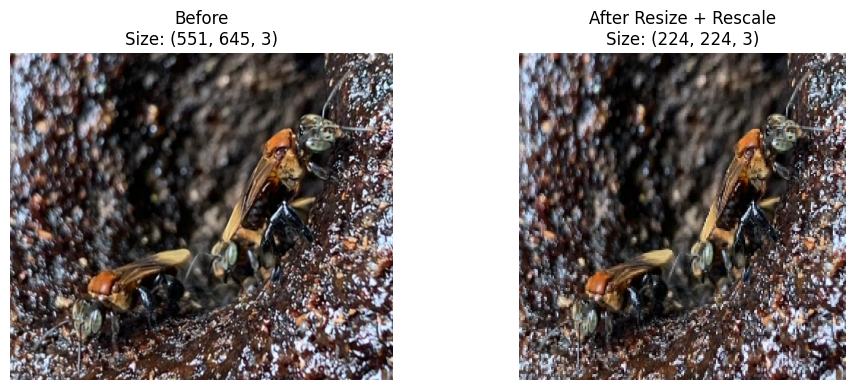

Pixel min/max BEFORE : 0.0 255.0
Pixel min/max AFTER  : 0.0 1.0


In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array


BASE = "/content/drive/MyDrive/Dataset_Split/train"

# pilih salah satu kelas (otomatis)
kelas = os.listdir(BASE)[0]
kelas_path = os.path.join(BASE, kelas)

# ambil satu gambar pertama
img_name = os.listdir(kelas_path)[99]
img_path = os.path.join(kelas_path, img_name)

print("Kelas:", kelas)
print("File:", img_name)
print("Path:", img_path)

# BEFORE
img_original = load_img(img_path)
img_original_arr = img_to_array(img_original)

# AFTER (RESIZE + RESCALE)
IMG_SIZE = (224, 224)
img_processed = load_img(img_path, target_size=IMG_SIZE)
img_processed_arr = img_to_array(img_processed) / 255.0  # rescale

# VISUALISASI
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img_original_arr.astype("uint8"))
plt.title(f"Before\nSize: {img_original_arr.shape}")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img_processed_arr)
plt.title(f"After Resize + Rescale\nSize: {img_processed_arr.shape}")
plt.axis("off")

plt.tight_layout()
plt.show()


print("Pixel min/max BEFORE :", img_original_arr.min(), img_original_arr.max())
print("Pixel min/max AFTER  :", img_processed_arr.min(), img_processed_arr.max())

training vgg default

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import os, json

BASE = "/content/drive/MyDrive/Dataset_Split"

TRAIN_DIR = os.path.join(BASE,"train")
VAL_DIR   = os.path.join(BASE,"val")

IMG_SIZE = (224,224)
BATCH = 32
EPOCH = 50

datagen = ImageDataGenerator(rescale=1./255)

train_gen = datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode="categorical",
    shuffle=True
)

val_gen = datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode="categorical",
    shuffle=False)

NUM_CLASSES = train_gen.num_classes

#Load VGG-16 pre-trained
base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)
#Layer yang dibekukan
for layer in base_model.layers:
    layer.trainable = False

# Bangun classifier
inp = Input(shape=(224,224,3))
x = base_model(inp, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)
out = Dense(NUM_CLASSES, activation="softmax")(x)

model_baseline = Model(inp,out)

# Compile model
model_baseline.compile(
    optimizer=Adam(1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model_baseline.summary()

history_baseline = model_baseline.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCH,
    verbose=1
)

model_baseline.save("/content/drive/MyDrive/model_baseline.h5")

with open("/content/drive/MyDrive/history_baseline.json","w") as f:
    json.dump(history_baseline.history,f)



Found 560 images belonging to 4 classes.
Found 120 images belonging to 4 classes.


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,868 (56.38 MB)

 Trainable params: 66,180 (258.52 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 13s 507ms/step - accuracy: 0.2840 - loss: 1.4628 - val_accuracy: 0.3083 - val_loss: 1.3625
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 399ms/step - accuracy: 0.2130 - loss: 1.4603 - val_accuracy: 0.3917 - val_loss: 1.3354
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 346ms/step - accuracy: 0.3560 - loss: 1.4131 - val_accuracy: 0.3833 - val_loss: 1.3132
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 399ms/step - accuracy: 0.3444 - loss: 1.3682 - val_accuracy: 0.4250 - val_loss: 1.2921
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 338ms/step - accuracy: 0.3773 - loss: 1.2959 - val_accuracy: 0.4500 - val_loss: 1.2707
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 417ms/step - accuracy: 0.3559 - loss: 1.3147 - val_accuracy: 0.4667 - val_loss: 1.2512
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 350ms/step - accuracy: 0.3981 - loss: 1.2702 - val_accuracy: 0.5417 - val_loss: 1.2323
Epoch 8/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 455ms/step - accuracy: 0.4264 - loss: 1.2426 - val_accuracy: 0

In [ ]:
import json
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

BASE = "/content/drive/MyDrive/Dataset_Split"
TRAIN_DIR = os.path.join(BASE,"train")

IMG_SIZE = (224,224)
BATCH = 32

datagen = ImageDataGenerator(rescale=1./255)

train_gen = datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode="categorical",
    shuffle=False
)

# simpan mapping kelas
with open("/content/drive/MyDrive/class_indices.json","w") as f:
    json.dump(train_gen.class_indices, f)

print("Class indices saved:", train_gen.class_indices)

Found 560 images belonging to 4 classes.
Class indices saved: {'Geniotrigona thoracica': 0, 'Tetragonula laeviceps': 1, 'Tetragonula testaceitarsis': 2, 'Tetrigona binghami': 3}


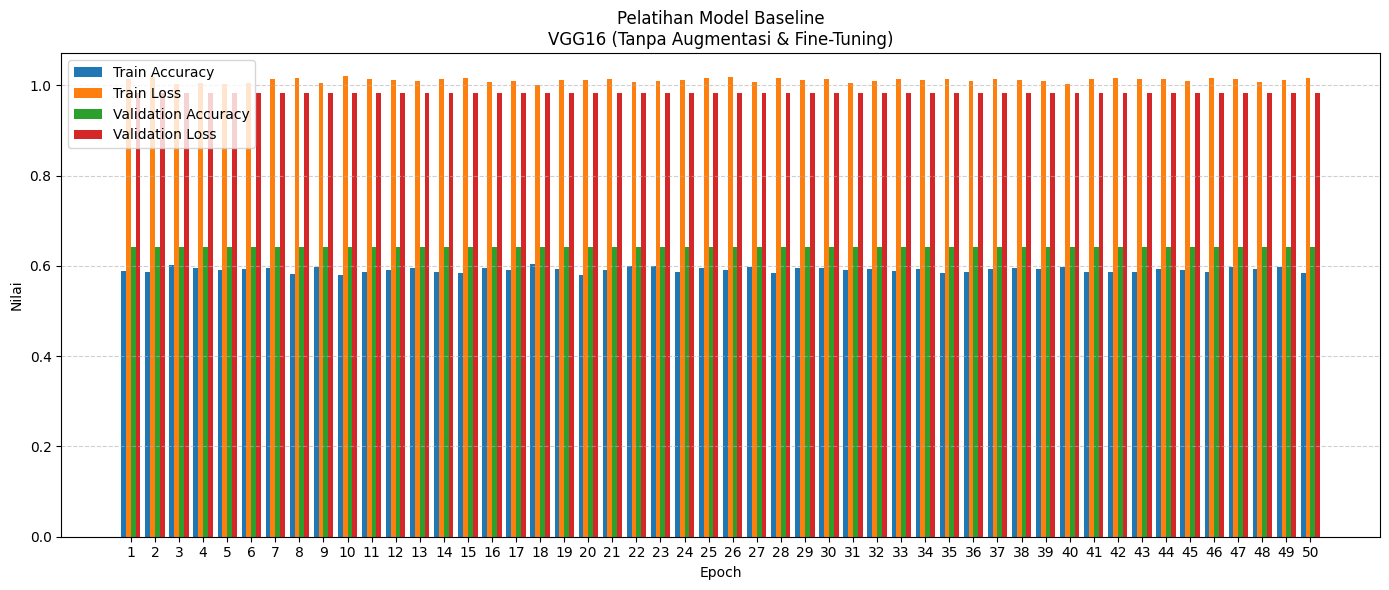

In [ ]:
import json
import matplotlib.pyplot as plt
import numpy as np

# LOAD HISTORY BASELINE
with open("/content/drive/MyDrive/history_baseline.json","w") as f:
    json.dump(history_baseline.history,f)

# AMBIL DATA
acc      = history["accuracy"]
val_acc  = history["val_accuracy"]
loss     = history["loss"]
val_loss = history["val_loss"]

epochs = range(1, len(acc) + 1)

# BAR WIDTH
width = 0.2
x = np.arange(len(epochs))

# PLOT BAR CHART
plt.figure(figsize=(14,6))

plt.bar(x - width*1.5, acc, width, label="Train Accuracy")
plt.bar(x - width/2, loss, width, label="Train Loss")
plt.bar(x + width/2, val_acc, width, label="Validation Accuracy")
plt.bar(x + width*1.5, val_loss, width, label="Validation Loss")

plt.xticks(x, epochs)
plt.xlabel("Epoch")
plt.ylabel("Nilai")
plt.title("Pelatihan Model Baseline\nVGG16 (Tanpa Augmentasi & Fine-Tuning)")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()


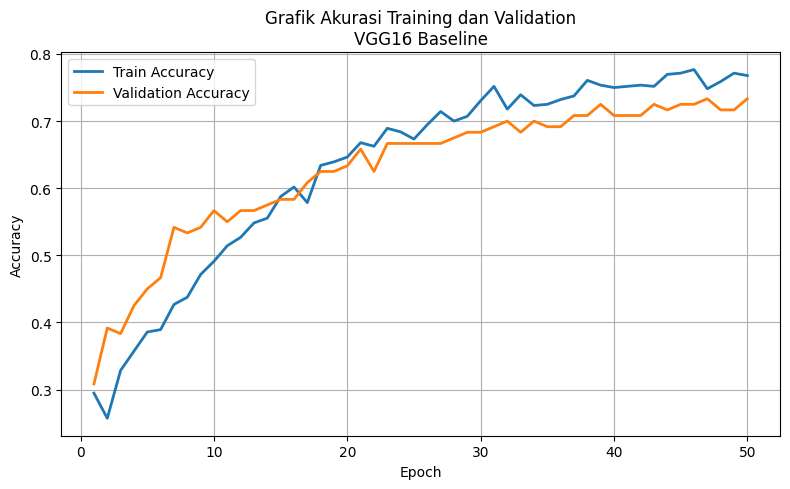

In [ ]:
import json
import matplotlib.pyplot as plt

# LOAD HISTORY BASELINE
with open("/content/drive/MyDrive/history_baseline.json", "r") as f:
    history = json.load(f)

# AMBIL DATA
train_acc = history["accuracy"]
val_acc = history["val_accuracy"]

epochs = range(1, len(train_acc) + 1)

# PLOT LINE CHART
plt.figure(figsize=(8,5))

plt.plot(epochs, train_acc, label="Train Accuracy", linewidth=2)
plt.plot(epochs, val_acc, label="Validation Accuracy", linewidth=2)

# LABEL & TITLE
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Grafik Akurasi Training dan Validation\nVGG16 Baseline")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


FT + Dataset asli

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model
from tensorflow.keras.optimizers import Adam
import os, json

BASE = "/content/drive/MyDrive/Dataset_Split"

TRAIN_DIR = os.path.join(BASE,"train")
VAL_DIR   = os.path.join(BASE,"val")

IMG_SIZE = (224,224)
BATCH = 32
EPOCH = 50

# DATA GENERATOR (NO AUG)
datagen = ImageDataGenerator(rescale=1./255)

train_gen = datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode="categorical",
    shuffle=True)

val_gen = datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode="categorical",
    shuffle=False)

# LOAD MODEL BASELINE
model_ft = load_model("/content/drive/MyDrive/model_baseline.h5")

print("Model loaded")

# FREEZE SEMUA DULU
for layer in model_ft.layers:
    layer.trainable = False

# UNFREEZE BLOCK5 VGG16
for layer in model_ft.layers:
    if "block5" in layer.name:
        layer.trainable = True

# cek layer trainable
print("\nLayer yang di‑fine‑tune:")
for layer in model_ft.layers:
    if layer.trainable:
        print(layer.name)

# COMPILE ULANG (LR KECIL)
model_ft.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model_ft.summary()

# TRAINING
history_ft = model_ft.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCH,
    verbose=1
)

# SAVE MODEL
model_ft.save("/content/drive/MyDrive/model_finetune_original.h5")

with open("/content/drive/MyDrive/history_finetune_original.json", "w") as f:
    json.dump(history_ft.history, f)


print("Fine‑tuning dataset asli selesai")


Found 560 images belonging to 4 classes.
Found 120 images belonging to 4 classes.


Model loaded

Layer yang di‑fine‑tune:


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,868 (56.38 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,780,868 (56.38 MB)

Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 13s 508ms/step - accuracy: 0.7730 - loss: 0.7162 - val_accuracy: 0.7333 - val_loss: 0.7954
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 375ms/step - accuracy: 0.7575 - loss: 0.7275 - val_accuracy: 0.7333 - val_loss: 0.7954
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 337ms/step - accuracy: 0.7438 - loss: 0.7719 - val_accuracy: 0.7333 - val_loss: 0.7954
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 385ms/step - accuracy: 0.7254 - loss: 0.7576 - val_accuracy: 0.7333 - val_loss: 0.7954
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 352ms/step - accuracy: 0.7875 - loss: 0.7024 - val_accuracy: 0.7333 - val_loss: 0.7954
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 383ms/step - accuracy: 0.7862 - loss: 0.7233 - val_accuracy: 0.7333 - val_loss: 0.7954
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 339ms/step - accuracy: 0.7639 - loss: 0.7501 - val_accuracy: 0.7333 - val_loss: 0.7954
Epoch 8/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 374ms/step - accuracy: 0.7625 - loss: 0.7425 - val_accuracy: 0

Fine‑tuning dataset asli selesai


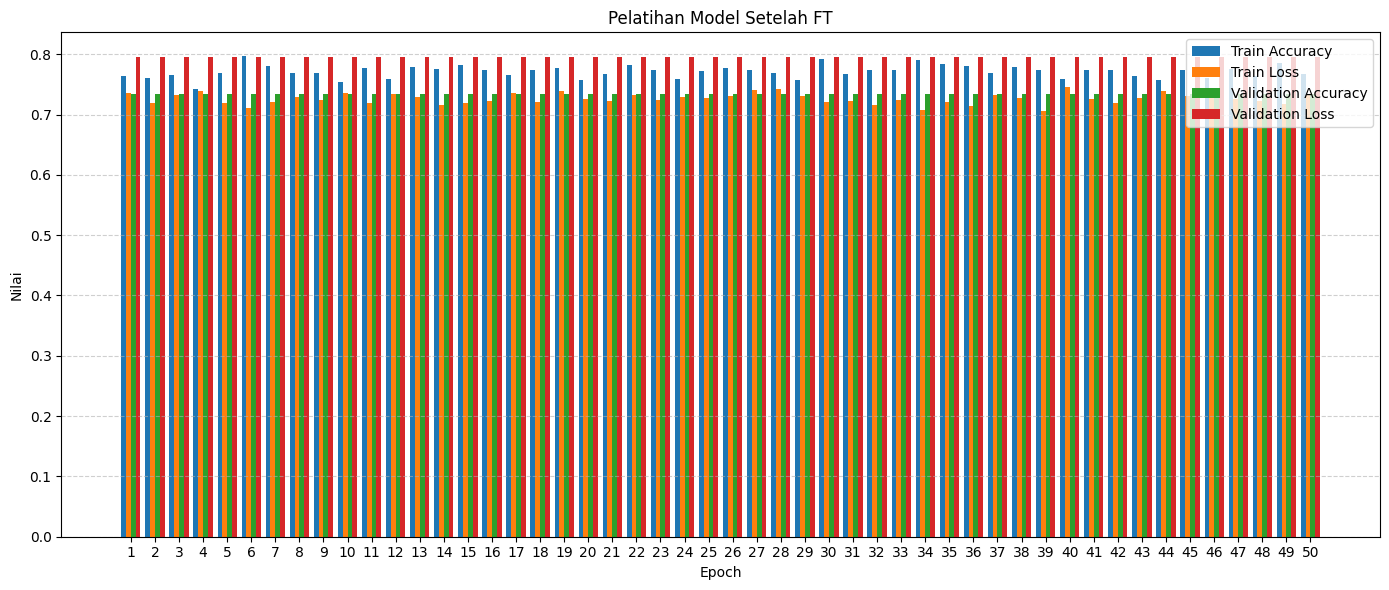

In [ ]:
import json
import matplotlib.pyplot as plt
import numpy as np

# LOAD HISTORY
with open("/content/drive/MyDrive/history_finetune_original.json", "w") as f:
    json.dump(history_ft.history, f)

# AMBIL DATA
acc = history["accuracy"]
val_acc = history["val_accuracy"]
loss = history["loss"]
val_loss = history["val_loss"]

epochs = range(1, len(acc) + 1)

# BAR WIDTH
width = 0.2
x = np.arange(len(epochs))

# PLOT BAR CHART
plt.figure(figsize=(14,6))

plt.bar(x - width*1.5, acc, width, label="Train Accuracy")
plt.bar(x - width/2, loss, width, label="Train Loss")
plt.bar(x + width/2, val_acc, width, label="Validation Accuracy")
plt.bar(x + width*1.5, val_loss, width, label="Validation Loss")

plt.xticks(x, epochs)
plt.xlabel("Epoch")
plt.ylabel("Nilai")
plt.title("Pelatihan Model Setelah FT")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()


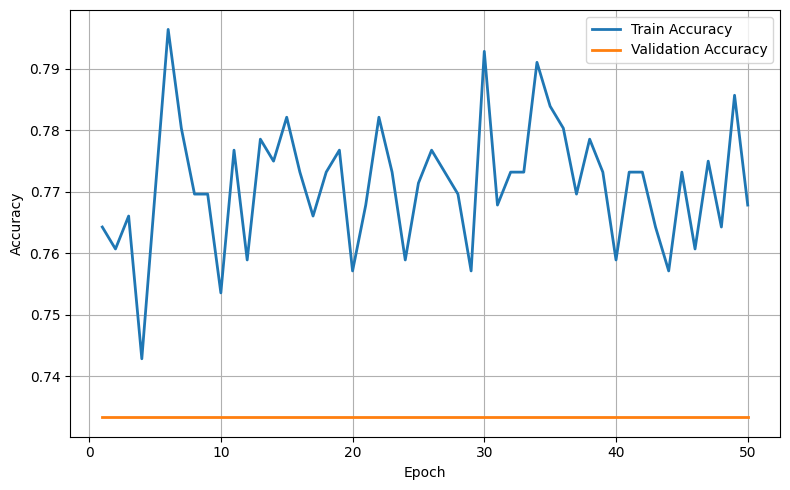

In [ ]:
import json
import matplotlib.pyplot as plt

# LOAD HISTORY FINE-TUNING
with open("/content/drive/MyDrive/history_finetune_original.json", "w") as f:
    json.dump(history_ft.history, f)


train_acc = history_ft.history["accuracy"]
val_acc   = history_ft.history["val_accuracy"]
train_loss = history_ft.history["loss"]
val_loss   = history_ft.history["val_loss"]


# PLOT
plt.figure(figsize=(8,5))
plt.plot(epochs, train_acc, label="Train Accuracy", linewidth=2)
plt.plot(epochs, val_acc, label="Validation Accuracy", linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Proses Augmentasi Data

In [ ]:
import os
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from PIL import Image

BASE_TRAIN = "/content/drive/MyDrive/Dataset_Split/train"
OUTPUT_AUG = "/content/drive/MyDrive/Dataset_Train_Augmented"
IMG_SIZE = (224,224)

os.makedirs(OUTPUT_AUG, exist_ok=True)

for cls in os.listdir(BASE_TRAIN):

    cls_path = os.path.join(BASE_TRAIN, cls)
    if not os.path.isdir(cls_path):
        continue

    out_cls = os.path.join(OUTPUT_AUG, cls)
    os.makedirs(out_cls, exist_ok=True)

    images = os.listdir(cls_path)

    print(f"Memproses kelas: {cls}")
    print(f"Jumlah gambar asli: {len(images)}")

    for img_name in images:

        img_path = os.path.join(cls_path, img_name)

        # Load & resize
        img = load_img(img_path, target_size=IMG_SIZE)
        x = img_to_array(img).astype("uint8")

        # Simpan gambar asli
        Image.fromarray(x).save(os.path.join(out_cls, img_name))

        h, w, _ = x.shape

        # ROTASI (20 derajat)
        rotated = Image.fromarray(x).rotate(20)
        rotated.save(os.path.join(out_cls, f"rot_{img_name}"))

        # ZOOM (crop tengah 20%)
        zoom_factor = 0.2
        crop_h = int(h * (1 - zoom_factor))
        crop_w = int(w * (1 - zoom_factor))
        start_h = (h - crop_h) // 2
        start_w = (w - crop_w) // 2

        cropped = x[start_h:start_h+crop_h, start_w:start_w+crop_w]
        zoomed = Image.fromarray(cropped).resize(IMG_SIZE)
        zoomed.save(os.path.join(out_cls, f"zoom_{img_name}"))

        # FLIP HORIZONTAL
        flipped = Image.fromarray(x).transpose(Image.FLIP_LEFT_RIGHT)
        flipped.save(os.path.join(out_cls, f"flip_{img_name}"))

        # WIDTH SHIFT (geser horizontal 10%)
        shift_w = int(0.1 * w)
        width_shifted = np.roll(x, shift_w, axis=1)
        Image.fromarray(width_shifted).save(
            os.path.join(out_cls, f"wshift_{img_name}")
        )

        # HEIGHT SHIFT (geser vertikal 10%)
        shift_h = int(0.1 * h)
        height_shifted = np.roll(x, shift_h, axis=0)
        Image.fromarray(height_shifted).save(
            os.path.join(out_cls, f"hshift_{img_name}")
        )

print("Augmentasi selesai untuk semua kelas")


Memproses kelas: Tetrigona binghami
Jumlah gambar asli: 183
Memproses kelas: Geniotrigona thoracica
Jumlah gambar asli: 193
Memproses kelas: Tetragonula laeviceps
Jumlah gambar asli: 193
Memproses kelas: Tetragonula testaceitarsis
Jumlah gambar asli: 184
Augmentasi selesai untuk semua kelas ✅


In [ ]:
import os

OUTPUT_AUG = "/content/drive/MyDrive/Dataset_Train_Augmented"

for cls in os.listdir(OUTPUT_AUG):
    cls_path = os.path.join(OUTPUT_AUG, cls)
    if not os.path.isdir(cls_path):
        continue

    n = len(os.listdir(cls_path))
    print(cls, n)

Geniotrigona thoracica 840
Tetragonula laeviceps 840
Tetragonula testaceitarsis 840
Tetrigona binghami 840


FT + Augmentasi

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model
from tensorflow.keras.optimizers import Adam
import os, json

# 1. LOAD DATA
TRAIN_DIR = "/content/drive/MyDrive/Dataset_Train_Augmented"
VAL_DIR   = "/content/drive/MyDrive/Dataset_Split/val"

# 2. PRE-PROCESSING
IMG_SIZE = (224,224)

# 3. PARAMETER
BATCH = 32
EPOCH = 50
LR    = 1e-5

MODEL_OUT   = "/content/drive/MyDrive/model_afterAug_FT_final.h5"
HISTORY_OUT = "/content/drive/MyDrive/history_afterAug_FT_final.json"

# 4. DATA GENERATOR
train_gen = ImageDataGenerator(
    rescale=1./255
).flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode="categorical",
    shuffle=True
)

val_gen = ImageDataGenerator(
    rescale=1./255
).flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode="categorical",
    shuffle=False
)

print("Train samples:", train_gen.samples)
print("Val samples  :", val_gen.samples)

# 5. LOAD MODEL (MODEL SEBELUM FT)
model_ft = load_model("/content/drive/MyDrive/model_afterAug_nonFT.h5")
print("Model loaded ")

# 6. LAYER TRAINABLE
# Freeze semua layer
for layer in model_ft.layers:
    layer.trainable = False

# Unfreeze block5 VGG16
for layer in model_ft.layers:
    if "block5" in layer.name:
        layer.trainable = True

print("\nLayer yang di‑fine‑tune:")
for layer in model_ft.layers:
    if layer.trainable:
        print(layer.name)

# 7. BANGUN CLASSIFIER
# (SUDAH ADA DARI MODEL YANG SEBELUMNYA)

# 8. COMPILE MODEL
model_ft.compile(
    optimizer=Adam(learning_rate=LR),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# 9. MODEL SUMMARY
model_ft.summary()

# 10. TRAINING
history_ft = model_ft.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCH,
    verbose=1
)

# 11. SAVE MODEL
model_ft.save(MODEL_OUT)
print("Model saved :", MODEL_OUT)

# 12. SAVE HISTORY (ANTI 0 BYTE)
with open(HISTORY_OUT, "w") as f:
    json.dump(history_ft.history, f, indent=2)

print("History saved:", HISTORY_OUT)
print("Fine‑tuning selesai ")


Found 3360 images belonging to 4 classes.
Found 120 images belonging to 4 classes.
Train samples: 3360
Val samples  : 120


Model loaded ✅

Layer yang di‑fine‑tune:


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,868 (56.38 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,780,868 (56.38 MB)

Epoch 1/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 25s 209ms/step - accuracy: 0.6076 - loss: 0.9927 - val_accuracy: 0.6417 - val_loss: 0.9835
Epoch 2/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 21s 196ms/step - accuracy: 0.5981 - loss: 1.0126 - val_accuracy: 0.6417 - val_loss: 0.9835
Epoch 3/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 20s 189ms/step - accuracy: 0.6183 - loss: 0.9935 - val_accuracy: 0.6417 - val_loss: 0.9835
Epoch 4/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 20s 188ms/step - accuracy: 0.6021 - loss: 1.0084 - val_accuracy: 0.6417 - val_loss: 0.9835
Epoch 5/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 20s 188ms/step - accuracy: 0.5993 - loss: 0.9937 - val_accuracy: 0.6417 - val_loss: 0.9835
Epoch 6/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 20s 192ms/step - accuracy: 0.6012 - loss: 0.9957 - val_accuracy: 0.6417 - val_loss: 0.9835
Epoch 7/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 20s 190ms/step - accuracy: 0.6056 - loss: 1.0004 - val_accuracy: 0.6417 - val_loss: 0.9835
Epoch 8/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 20s 191ms/step - accuracy: 0.5719 - loss: 1

Model saved : /content/drive/MyDrive/model_afterAug_FT_final.h5
History saved: /content/drive/MyDrive/history_afterAug_FT_final.json
Fine‑tuning selesai ✅


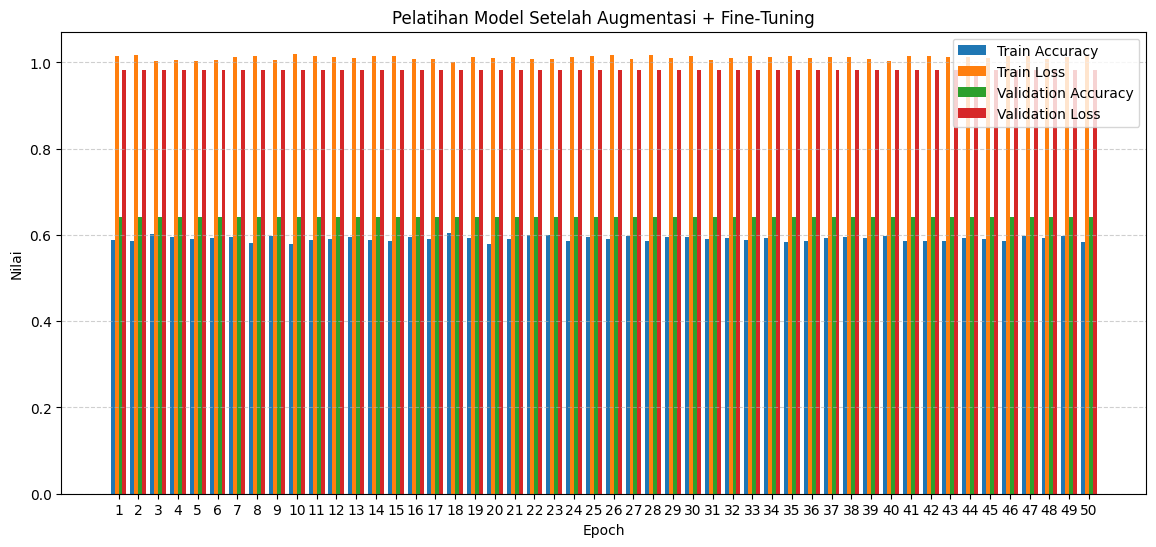

In [ ]:
import json
import matplotlib.pyplot as plt
import numpy as np

with open("/content/drive/MyDrive/history_afterAug_FT_final.json") as f:
    history = json.load(f)

train_acc = history["accuracy"]
val_acc   = history["val_accuracy"]
train_loss = history["loss"]
val_loss   = history["val_loss"]

epochs = range(1, len(train_acc) + 1)

bar_width = 0.2
x = np.arange(len(epochs))

plt.figure(figsize=(14,6))

plt.bar(x - 1.5*bar_width, train_acc,  bar_width, label="Train Accuracy")
plt.bar(x - 0.5*bar_width, train_loss, bar_width, label="Train Loss")
plt.bar(x + 0.5*bar_width, val_acc,    bar_width, label="Validation Accuracy")
plt.bar(x + 1.5*bar_width, val_loss,   bar_width, label="Validation Loss")

plt.xticks(x, epochs)
plt.xlabel("Epoch")
plt.ylabel("Nilai")
plt.title("Pelatihan Model Setelah Augmentasi + Fine‑Tuning")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


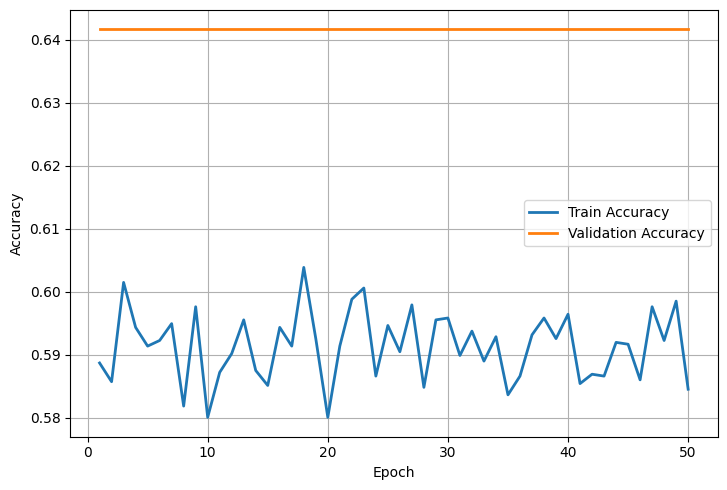

In [ ]:
import json
import matplotlib.pyplot as plt
from google.colab import drive

drive.mount('/content/drive')

with open("/content/drive/MyDrive/history_afterAug_FT_final.json", "r") as f:
    history = json.load(f)

train_acc  = history["accuracy"]
val_acc    = history["val_accuracy"]
train_loss = history["loss"]
val_loss   = history["val_loss"]

epochs = range(1, len(train_acc) + 1)

plt.style.use("default")

plt.figure(figsize=(14,5))

# accuracy
plt.subplot(1,2,1)
plt.plot(epochs, train_acc, linewidth=2, label="Train Accuracy")
plt.plot(epochs, val_acc, linewidth=2, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
# @title
import tensorflow as tf
tf.config.list_physical_devices('GPU')


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

Perbandingan ketiga skena

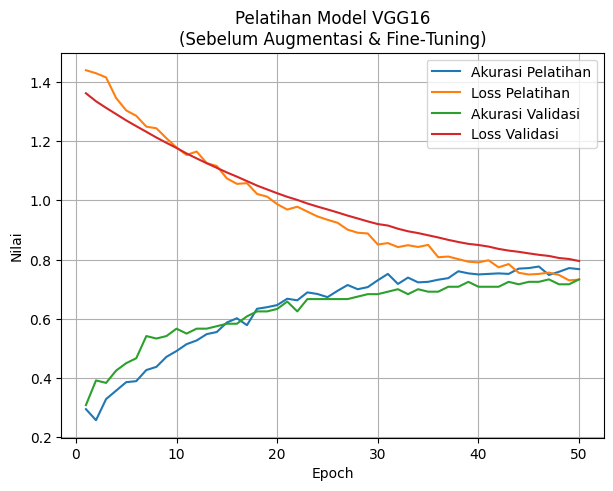

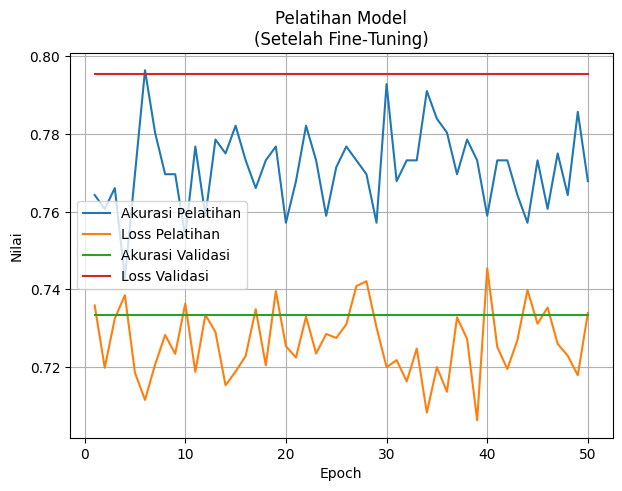

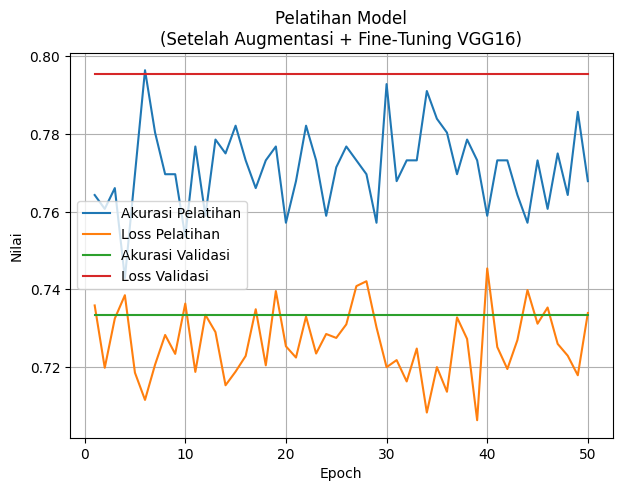

In [ ]:
import json
import matplotlib.pyplot as plt

# load history baseline
with open("/content/drive/MyDrive/history_baseline.json") as f:
    h = json.load(f)

epochs = range(1, len(h["accuracy"]) + 1)

plt.figure(figsize=(7,5))
plt.plot(epochs, h["accuracy"], label="Akurasi Pelatihan")
plt.plot(epochs, h["loss"], label="Loss Pelatihan")
plt.plot(epochs, h["val_accuracy"], label="Akurasi Validasi")
plt.plot(epochs, h["val_loss"], label="Loss Validasi")

plt.title("Pelatihan Model VGG16\n(Sebelum Augmentasi & Fine‑Tuning)")
plt.xlabel("Epoch")
plt.ylabel("Nilai")
plt.legend()
plt.grid(True)
plt.show()

# load history fine-tuning original
with open("/content/drive/MyDrive/history_finetune_original.json") as f:
    h = json.load(f)

epochs = range(1, len(h["accuracy"]) + 1)

plt.figure(figsize=(7,5))
plt.plot(epochs, h["accuracy"], label="Akurasi Pelatihan")
plt.plot(epochs, h["loss"], label="Loss Pelatihan")
plt.plot(epochs, h["val_accuracy"], label="Akurasi Validasi")
plt.plot(epochs, h["val_loss"], label="Loss Validasi")

plt.title("Pelatihan Model\n(Setelah Fine‑Tuning)")
plt.xlabel("Epoch")
plt.ylabel("Nilai")
plt.legend()
plt.grid(True)
plt.show()

# load history after augmentation + fine-tuning
import json

HISTORY_OUT = "/content/drive/MyDrive/history_afterAug_FT_final.json"

epochs = range(1, len(h["accuracy"]) + 1)

plt.figure(figsize=(7,5))
plt.plot(epochs, h["accuracy"], label="Akurasi Pelatihan")
plt.plot(epochs, h["loss"], label="Loss Pelatihan")
plt.plot(epochs, h["val_accuracy"], label="Akurasi Validasi")
plt.plot(epochs, h["val_loss"], label="Loss Validasi")

plt.title("Pelatihan Model\n(Setelah Augmentasi + Fine‑Tuning VGG16)")
plt.xlabel("Epoch")
plt.ylabel("Nilai")
plt.legend()
plt.grid(True)
plt.show()

Found 120 images belonging to 4 classes.
Classes: ['Geniotrigona thoracica', 'Tetragonula laeviceps', 'Tetragonula testaceitarsis', 'Tetrigona binghami']

Skenario 1 - VGG16 Default (Sebelum Augmentasi & FT)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


4/4 ━━━━━━━━━━━━━━━━━━━━ 51s 13s/step

Classification Report:
                            precision    recall  f1-score   support

    Geniotrigona thoracica     0.7273    0.8000    0.7619        30
     Tetragonula laeviceps     0.7576    0.8333    0.7937        30
Tetragonula testaceitarsis     0.8000    0.8000    0.8000        30
        Tetrigona binghami     0.7083    0.5667    0.6296        30

                  accuracy                         0.7500       120
                 macro avg     0.7483    0.7500    0.7463       120
              weighted avg     0.7483    0.7500    0.7463       120



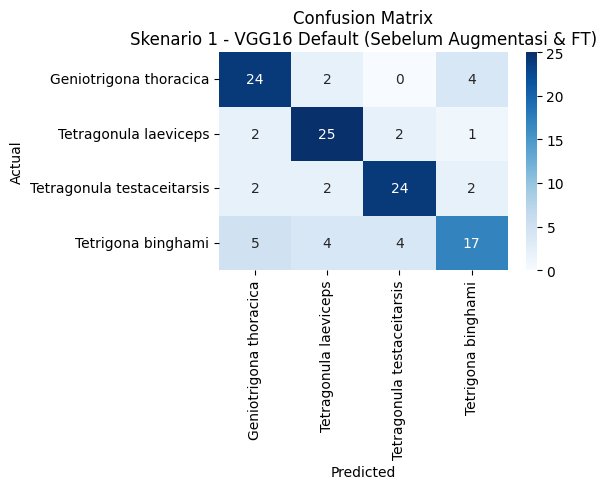


Skenario 2 - Fine-Tuning + Sebelum Augmentasi


4/4 ━━━━━━━━━━━━━━━━━━━━ 47s 11s/step

Classification Report:
                            precision    recall  f1-score   support

    Geniotrigona thoracica     0.7273    0.8000    0.7619        30
     Tetragonula laeviceps     0.7576    0.8333    0.7937        30
Tetragonula testaceitarsis     0.8000    0.8000    0.8000        30
        Tetrigona binghami     0.7083    0.5667    0.6296        30

                  accuracy                         0.7500       120
                 macro avg     0.7483    0.7500    0.7463       120
              weighted avg     0.7483    0.7500    0.7463       120



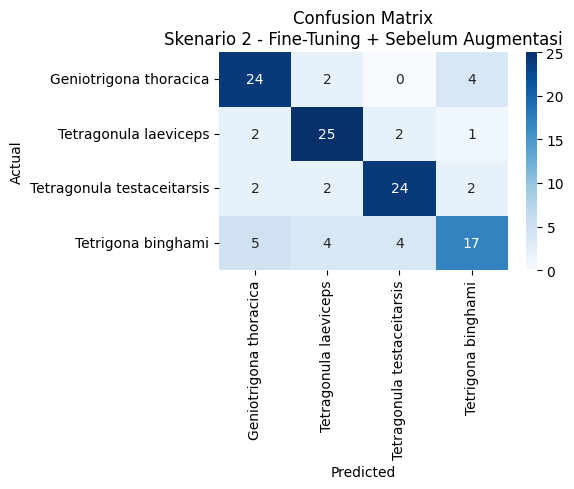


Skenario 3 - Fine-Tuning + Augmentasi


3/4 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 47s 11s/step

Classification Report:
                            precision    recall  f1-score   support

    Geniotrigona thoracica     0.5833    0.7000    0.6364        30
     Tetragonula laeviceps     0.6207    0.6000    0.6102        30
Tetragonula testaceitarsis     0.7857    0.7333    0.7586        30
        Tetrigona binghami     0.5556    0.5000    0.5263        30

                  accuracy                         0.6333       120
                 macro avg     0.6363    0.6333    0.6329       120
              weighted avg     0.6363    0.6333    0.6329       120



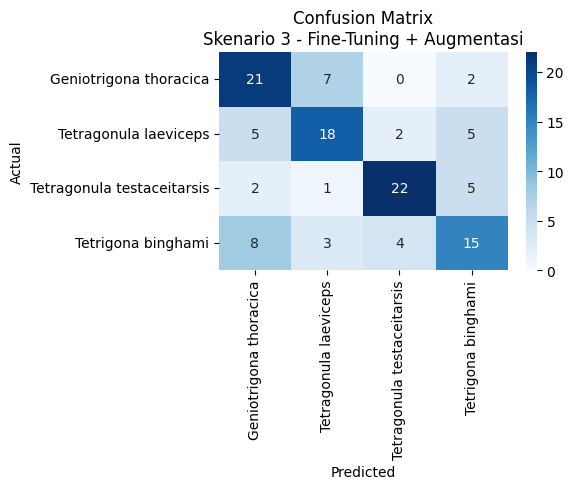

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix

# 1. LOAD TEST DATA
TEST_DIR = "/content/drive/MyDrive/Dataset_Split/test"
IMG_SIZE = (224,224)
BATCH = 32

test_gen = ImageDataGenerator(
    rescale=1./255
).flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode="categorical",
    shuffle=False
)

class_names = list(test_gen.class_indices.keys())
print("Classes:", class_names)

# 2. FUNGSI EVALUASI MODEL
def evaluate_model(model_path, title):
    print("\n" + "="*60)
    print(title)
    print("="*60)

    model = load_model(model_path)

    # PREDIKSI
    preds = model.predict(test_gen)
    y_pred = np.argmax(preds, axis=1)
    y_true = test_gen.classes

    # CLASSIFICATION REPORT
    print("\nClassification Report:")
    print(classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    ))

    # CONFUSION MATRIX
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.title(f"Confusion Matrix\n{title}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

# VGG16 default
evaluate_model(
    "/content/drive/MyDrive/model_baseline.h5",
    "Skenario 1 - VGG16 Default (Sebelum Augmentasi & FT)"
)

# Fine-Tuning tanpa Augmentasi
evaluate_model(
    "/content/drive/MyDrive/model_finetune_original.h5",
    "Skenario 2 - Fine-Tuning + Sebelum Augmentasi"
)

# Fine-Tuning + Augmentasi
evaluate_model(
    "/content/drive/MyDrive/model_afterAug_FT_final.h5",
    "Skenario 3 - Fine-Tuning + Augmentasi"
)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

TEST_DIR = "/content/drive/MyDrive/Dataset_Split/test"
IMG_SIZE = (224, 224)
BATCH = 32

test_gen = ImageDataGenerator(
    rescale=1./255
).flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode="categorical",
    shuffle=False
)

class_names = list(test_gen.class_indices.keys())
print(class_names)


Found 120 images belonging to 4 classes.
['Geniotrigona thoracica', 'Tetragonula laeviceps', 'Tetragonula testaceitarsis', 'Tetrigona binghami']


In [ ]:
import numpy as np
from sklearn.metrics import classification_report
from tensorflow.keras.models import load_model

def get_cr_scores(model_path):
    model = load_model(model_path)

    preds = model.predict(test_gen, verbose=0)
    y_pred = np.argmax(preds, axis=1)
    y_true = test_gen.classes

    report = classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        output_dict=True
    )

    return {
        "precision": report["macro avg"]["precision"],
        "recall": report["macro avg"]["recall"],
        "f1": report["macro avg"]["f1-score"],
        "macro_f1": report["macro avg"]["f1-score"],
        "weighted_f1": report["weighted avg"]["f1-score"]
    }


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from tensorflow.keras.models import load_model

def get_cr_scores(model_path, test_gen, class_names):
    model = load_model(model_path)

    preds = model.predict(test_gen, verbose=0)
    y_pred = np.argmax(preds, axis=1)
    y_true = test_gen.classes

    report = classification_report(
        y_true, y_pred,
        target_names=class_names,
        output_dict=True
    )

    return {
        "precision": report["macro avg"]["precision"],
        "recall": report["macro avg"]["recall"],
        "f1": report["macro avg"]["f1-score"],
        "macro": report["macro avg"]["f1-score"],
        "weighted": report["weighted avg"]["f1-score"]
    }


In [ ]:
s1 = get_cr_scores(
    "/content/drive/MyDrive/model_baseline.h5",
    test_gen,
    class_names
)

s2 = get_cr_scores(
    "/content/drive/MyDrive/model_finetune_original.h5",
    test_gen,
    class_names
)

s3 = get_cr_scores(
    "/content/drive/MyDrive/model_afterAug_FT_final.h5",
    test_gen,
    class_names
)


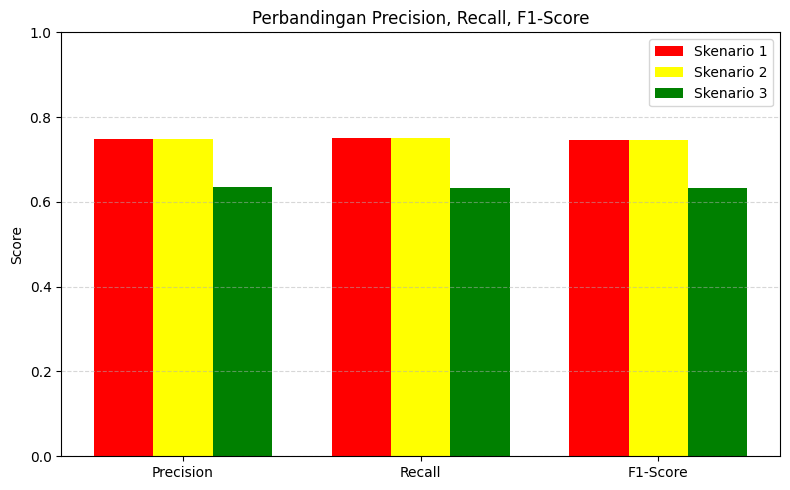

In [ ]:
labels = ["Precision", "Recall", "F1-Score"]
x = np.arange(len(labels))
width = 0.25

plt.figure(figsize=(8,5))

plt.bar(x - width, [s1["precision"], s1["recall"], s1["f1"]],
        width, label="Skenario 1", color="red")
plt.bar(x, [s2["precision"], s2["recall"], s2["f1"]],
        width, label="Skenario 2", color="yellow")
plt.bar(x + width, [s3["precision"], s3["recall"], s3["f1"]],
        width, label="Skenario 3", color="green")

plt.xticks(x, labels)
plt.ylim(0,1)
plt.ylabel("Score")
plt.title("Perbandingan Precision, Recall, F1-Score")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


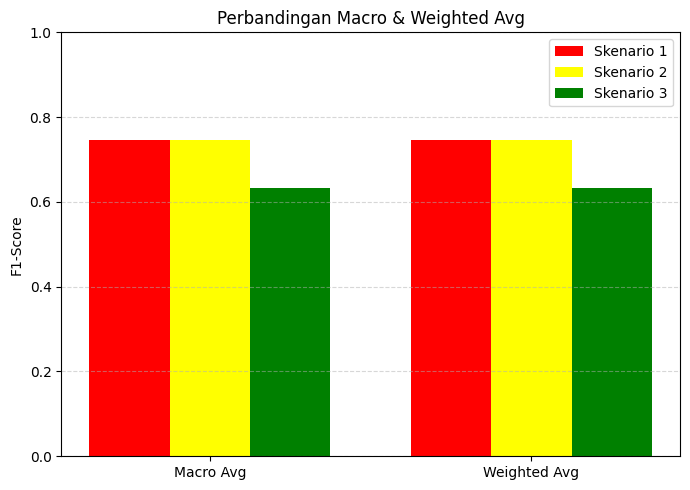

In [ ]:
labels = ["Macro Avg", "Weighted Avg"]
x = np.arange(len(labels))
width = 0.25

plt.figure(figsize=(7,5))

plt.bar(x - width, [s1["macro"], s1["weighted"]],
        width, label="Skenario 1", color="red")
plt.bar(x, [s2["macro"], s2["weighted"]],
        width, label="Skenario 2", color="yellow")
plt.bar(x + width, [s3["macro"], s3["weighted"]],
        width, label="Skenario 3", color="green")

plt.xticks(x, labels)
plt.ylim(0,1)
plt.ylabel("F1-Score")
plt.title("Perbandingan Macro & Weighted Avg")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()
